# Casadi

## About

1. software core written in C++  
2. bindings/interfaces for python, MATLAB
3. largely used by optimal control community
   1. building blocks for solving OCP

##  Features

1. gradient based nonlinear optimization
2. AD- differentiation of expression graphs of codes
3. not a symbolic/computer algebra system-symbolic primitives used to create the expression graphs
4. API to several nonlinear and QP optimization solvers 
5. nonlinear equations, numerical integration
6. supports code generation


# Installation and support

## Community support

1. Sourceforge (archived)
2. google groups (archived)
3. github discussion (active)

## Support the software

1. cite it if you have used it for any research material
2. star github
3. add contributions

```
@Article{Andersson2018,
Author = {Joel A E Andersson and Joris Gillis and Greg Horn
and James B Rawlings and Moritz Diehl},
Title = {{CasADi} -- {A} software framework for nonlinear optimization
and optimal control},
Journal = {Mathematical Programming Computation},
Year = {2018},
}
```

## Installation

1. Binaries - effortless
   1. pip install casadi
2. build from source code
   1. extra features
   2. openMP support, MA57 solver etc.

# Check installation

After installation, check by executing the following

In [1]:
import casadi as cs
import numpy as np

x=cs.SX.sym('x',1,1)
del(x)

# Symbolic framework


A symbolic primitive represents a entity that takes real values. This can be a variable, a vector or a matrix.

1. Everything is a **matrix** (MATLAB inspired) in casadi

    1. vector - n x 1 matrix
    2. scalar - 1 x 1 matrix

2. Create symbolic primitives using the sym static method. A scalar, row vector, column vector and matrix is created in the following lines of code. 

3. The symbolic primitive is a data structure aimed to create functions that are differentiable. Function simply takes some inputs and throws outputs.

4. In python everything is a class/object. The size of the symbolic primitive is accessed using the shape method defined in the symbolic object x.

5. 'x' indicates a name assigned to the variable x on LHS. It can be anything. In case of any error message displayed by casadi, the string will be used.
Note that in the $5 \times 5$ matrix, the string name is L. This will be used while printing messages to the console.

In [2]:
x=cs.MX.sym('x',1)
print(x,type(x),x.shape)
x=cs.MX.sym('x',1,5)
print(x,type(x),x.shape)
x=cs.MX.sym('x',5,1)
print(x,type(x),x.shape)
x=cs.MX.sym('L',5,5)
print(x,type(x),x.shape)
del(x)

x <class 'casadi.casadi.MX'> (1, 1)
x <class 'casadi.casadi.MX'> (1, 5)
x <class 'casadi.casadi.MX'> (5, 1)
L <class 'casadi.casadi.MX'> (5, 5)


# Data types in casadi

1. SX- for elementary operations
2. MX- matrix operations
3. DM- constants or numerical values

Combination of these leads to best results

# Special matrices
Apart from symbolic primitives, specialized matrices can also be created.

### Identity matrix

1. A sparse identity matrix is created. 
2. 00 denotes the sparse/structural zeros in the matrix.

In [3]:
I=cs.SX.eye(5)
print(I)
del(I)

@1=1, 
[[@1, 00, 00, 00, 00], 
 [00, @1, 00, 00, 00], 
 [00, 00, @1, 00, 00], 
 [00, 00, 00, @1, 00], 
 [00, 00, 00, 00, @1]]


### Zero matrix

#### dense matrix of $3 \times 5$ 

In [4]:
O=cs.SX.zeros(3,5)
print(O)
del(O)

@1=0, 
[[@1, @1, @1, @1, @1], 
 [@1, @1, @1, @1, @1], 
 [@1, @1, @1, @1, @1]]


#### sparse zero matrix of  $3 \times 5$ 

In [5]:
O=cs.SX(3,5)
print(O)
del(O)


[[00, 00, 00, 00, 00], 
 [00, 00, 00, 00, 00], 
 [00, 00, 00, 00, 00]]


### One matrix

Matrix whose elements are all ones

In [6]:
I=cs.SX.ones(2,5)
print(I)
del(I)

@1=1, 
[[@1, @1, @1, @1, @1], 
 [@1, @1, @1, @1, @1]]


### Repeated matrices

To repeat a matrix A, m times along the column and n times along the row use the repmat command

$\begin{equation}
B=\begin{bmatrix}
A&A\\
A&A\\
A&A
\end{bmatrix}
\end{equation}$

In [7]:
A=cs.SX([1,2,3])
print(A,A.shape)
B=cs.repmat(A,3,2)
print(B)
del(A)
del(B)


[1, 2, 3] (3, 1)
@1=1, @2=2, @3=3, 
[[@1, @1], 
 [@2, @2], 
 [@3, @3], 
 [@1, @1], 
 [@2, @2], 
 [@3, @3], 
 [@1, @1], 
 [@2, @2], 
 [@3, @3]]


# Typecast
A numpy/scipy matrix can be converted or typecasted to a casadi matrix.

In [8]:
Anum=np.array([[1,2,3],[4,5,6]])
print("Before typecast",'\n',Anum, type(Anum))
Acas=cs.SX(Anum)
print("Before typecast",'\n',Acas, type(Acas))
del(Anum)
del(Acas)

Before typecast 
 [[1 2 3]
 [4 5 6]] <class 'numpy.ndarray'>
Before typecast 
 
[[1, 2, 3], 
 [4, 5, 6]] <class 'casadi.casadi.SX'>


A list or list of list can be used to create a matrix

In [9]:
A=[[1,2,3],[4,5,6]]
print(A,type(A))
B=cs.SX(A)
print(B,type(B))

[[1, 2, 3], [4, 5, 6]] <class 'list'>

[[1, 2, 3], 
 [4, 5, 6]] <class 'casadi.casadi.SX'>


# Element-wise operations

Matrix vector multiplication with *

1. A scalar multiplied  using * will be multiplied to each element of the matrix
2. A vector multiplied using * will be multiplied element wise to each column of the matrix
3. A matrix multiplied using * will be multiplied  element wise to the matrix

The same holds for +,-and / operators.

In [10]:
A=cs.SX.sym('A',3,3)
x=cs.SX.sym('x',1,1)
X=cs.SX.sym('X',3,1)
B=cs.SX.sym('B',3,3)
print(A,A.shape)
print(x,x.shape)
print(A+x,(A+x).shape)
print((A+X),(A+X).shape)
print(A+B)


[[A_0, A_3, A_6], 
 [A_1, A_4, A_7], 
 [A_2, A_5, A_8]] (3, 3)
x (1, 1)

[[(A_0+x), (A_3+x), (A_6+x)], 
 [(A_1+x), (A_4+x), (A_7+x)], 
 [(A_2+x), (A_5+x), (A_8+x)]] (3, 3)

[[(A_0+X_0), (A_3+X_0), (A_6+X_0)], 
 [(A_1+X_1), (A_4+X_1), (A_7+X_1)], 
 [(A_2+X_2), (A_5+X_2), (A_8+X_2)]] (3, 3)

[[(A_0+B_0), (A_3+B_3), (A_6+B_6)], 
 [(A_1+B_1), (A_4+B_4), (A_7+B_7)], 
 [(A_2+B_2), (A_5+B_5), (A_8+B_8)]]


# Standard Matrix multiplication 

To perform the standard matrix  multiplication, use the operator @ or mtimes function.

Matrix matrix and matrix vector multiplication using '@' and mtimes.

In [11]:
A=cs.SX.sym('A',3,3)
B=cs.SX.sym('B',3,3)
X=cs.SX.sym('X',3,1)

print(A,A.shape)
print(B,B.shape)
print(X,X.shape)
print('A@B')
print((A@B))
print('mtimes(A,B)')
print(cs.mtimes(A,B))
print('A@X')
print(A@X)
print('mtimes(A,B)')
print(cs.mtimes(A,X))
del A,B,X



[[A_0, A_3, A_6], 
 [A_1, A_4, A_7], 
 [A_2, A_5, A_8]] (3, 3)

[[B_0, B_3, B_6], 
 [B_1, B_4, B_7], 
 [B_2, B_5, B_8]] (3, 3)
[X_0, X_1, X_2] (3, 1)
A@B

[[(((A_0*B_0)+(A_3*B_1))+(A_6*B_2)), (((A_0*B_3)+(A_3*B_4))+(A_6*B_5)), (((A_0*B_6)+(A_3*B_7))+(A_6*B_8))], 
 [(((A_1*B_0)+(A_4*B_1))+(A_7*B_2)), (((A_1*B_3)+(A_4*B_4))+(A_7*B_5)), (((A_1*B_6)+(A_4*B_7))+(A_7*B_8))], 
 [(((A_2*B_0)+(A_5*B_1))+(A_8*B_2)), (((A_2*B_3)+(A_5*B_4))+(A_8*B_5)), (((A_2*B_6)+(A_5*B_7))+(A_8*B_8))]]
mtimes(A,B)

[[(((A_0*B_0)+(A_3*B_1))+(A_6*B_2)), (((A_0*B_3)+(A_3*B_4))+(A_6*B_5)), (((A_0*B_6)+(A_3*B_7))+(A_6*B_8))], 
 [(((A_1*B_0)+(A_4*B_1))+(A_7*B_2)), (((A_1*B_3)+(A_4*B_4))+(A_7*B_5)), (((A_1*B_6)+(A_4*B_7))+(A_7*B_8))], 
 [(((A_2*B_0)+(A_5*B_1))+(A_8*B_2)), (((A_2*B_3)+(A_5*B_4))+(A_8*B_5)), (((A_2*B_6)+(A_5*B_7))+(A_8*B_8))]]
A@X
[(((A_0*X_0)+(A_3*X_1))+(A_6*X_2)), (((A_1*X_0)+(A_4*X_1))+(A_7*X_2)), (((A_2*X_0)+(A_5*X_1))+(A_8*X_2))]
mtimes(A,B)
[(((A_0*X_0)+(A_3*X_1))+(A_6*X_2)), (((A_1*X_0)+(A_4*X_1)

# Simplify the expressions

1. Note that casadi does not simplify expressions on its own. 
2. The expression graph is as good as the code we write.
3. complexity of expression graph can be checked counting the nodes in the graph
4. Use common sub-expression (**cse**) function to simplify the graph

In [12]:
A=cs.SX.sym('A',3,3)
B=cs.SX.sym('B',3,3)
print('Error')
e=(A@B-A@B)
print(e)
print('without cse','Nodes : ',cs.n_nodes(e))
e=cs.cse(A@B-A@B)
print(e)
print('with cse','Nodes : ',cs.n_nodes(e))
del A,B,e


Error

[[((((A_0*B_0)+(A_3*B_1))+(A_6*B_2))-(((A_0*B_0)+(A_3*B_1))+(A_6*B_2))), ((((A_0*B_3)+(A_3*B_4))+(A_6*B_5))-(((A_0*B_3)+(A_3*B_4))+(A_6*B_5))), ((((A_0*B_6)+(A_3*B_7))+(A_6*B_8))-(((A_0*B_6)+(A_3*B_7))+(A_6*B_8)))], 
 [((((A_1*B_0)+(A_4*B_1))+(A_7*B_2))-(((A_1*B_0)+(A_4*B_1))+(A_7*B_2))), ((((A_1*B_3)+(A_4*B_4))+(A_7*B_5))-(((A_1*B_3)+(A_4*B_4))+(A_7*B_5))), ((((A_1*B_6)+(A_4*B_7))+(A_7*B_8))-(((A_1*B_6)+(A_4*B_7))+(A_7*B_8)))], 
 [((((A_2*B_0)+(A_5*B_1))+(A_8*B_2))-(((A_2*B_0)+(A_5*B_1))+(A_8*B_2))), ((((A_2*B_3)+(A_5*B_4))+(A_8*B_5))-(((A_2*B_3)+(A_5*B_4))+(A_8*B_5))), ((((A_2*B_6)+(A_5*B_7))+(A_8*B_8))-(((A_2*B_6)+(A_5*B_7))+(A_8*B_8)))]]
without cse Nodes :  117
@1=0, 
[[@1, @1, @1], 
 [@1, @1, @1], 
 [@1, @1, @1]]
with cse Nodes :  1


# Matrix transpose

Use .T to transpose a matrix

In [13]:
A=cs.SX([[1,2],[3,4]])
print(A)
print('transpose')
print(A.T)
del A


[[1, 2], 
 [3, 4]]
transpose

[[1, 3], 
 [2, 4]]


# Matrix reshape

1. Change the shape of the matrix A from (a,b) to (c,d), such that a*b==c*d. 
2. A cheap operation.
3. **Take elements from the original matrix columns wise** and fill the new matrix

In [14]:
A=cs.SX([[1,2,3,4],[5,6,7,8],[9,10,11,12]])
print(A,A.shape)
B=cs.reshape(A,4,3)
print(B)
del A,B


[[1, 2, 3, 4], 
 [5, 6, 7, 8], 
 [9, 10, 11, 12]] (3, 4)

[[1, 6, 11], 
 [5, 10, 4], 
 [9, 3, 8], 
 [2, 7, 12]]


# Matrix concatenation

1. Stack matrix of appropriate size vertically or horizontally.
2. Due to CCS followed by casadi, it is efficient to stack along the columns or horizontally.

In [15]:
A=cs.SX.eye(3)
print(A,A.shape)
B=cs.SX.ones(3,3)
print(A,A.shape)
print('Horizontal')
print(cs.horzcat(A,B))
print('Vertical')
print(cs.vertcat(A,B))
del A,B

@1=1, 
[[@1, 00, 00], 
 [00, @1, 00], 
 [00, 00, @1]] (3, 3)
@1=1, 
[[@1, 00, 00], 
 [00, @1, 00], 
 [00, 00, @1]] (3, 3)
Horizontal
@1=1, 
[[@1, 00, 00, @1, @1, @1], 
 [00, @1, 00, @1, @1, @1], 
 [00, 00, @1, @1, @1, @1]]
Vertical
@1=1, 
[[@1, 00, 00], 
 [00, @1, 00], 
 [00, 00, @1], 
 [@1, @1, @1], 
 [@1, @1, @1], 
 [@1, @1, @1]]


A python list of casadi matrices can be concatenated using **hcat or \*list**

In [16]:
A=cs.SX.eye(3)
B=cs.SX.ones(3,3)
C=[A,B]
print('Horizontal')
print(cs.hcat(C))
print(cs.horzcat(*C))

print('Vertical')
print(cs.vcat(C))
print(cs.vertcat(*C))

del A,B,C


Horizontal
@1=1, 
[[@1, 00, 00, @1, @1, @1], 
 [00, @1, 00, @1, @1, @1], 
 [00, 00, @1, @1, @1, @1]]
@1=1, 
[[@1, 00, 00, @1, @1, @1], 
 [00, @1, 00, @1, @1, @1], 
 [00, 00, @1, @1, @1, @1]]
Vertical
@1=1, 
[[@1, 00, 00], 
 [00, @1, 00], 
 [00, 00, @1], 
 [@1, @1, @1], 
 [@1, @1, @1], 
 [@1, @1, @1]]
@1=1, 
[[@1, 00, 00], 
 [00, @1, 00], 
 [00, 00, @1], 
 [@1, @1, @1], 
 [@1, @1, @1], 
 [@1, @1, @1]]


# Inner product of matrix

$<A,B>= \sum_{i}^{}\sum_{j}^{} A_{i,j} B_{i,j}$

In [17]:
A=cs.SX([1,2,3])
B=cs.SX([4,5,6])

print("dot()",cs.dot(A,B))
# check
print("A.T@B",A.T@B)

del A,B

dot() 32
A.T@B 32


# Matrix properties

There are query commands and more are available on the API website

In [18]:
A=cs.SX([[1.1,2,3],[4,5,6],[7,8,9]])
print(A)
# rows and columns
print(A.shape)
# rows
print(A.size1())
# columns
print(A.size2())
# number of elements
print(A.numel())
# number of nonzeros
print(A.nnz())
# sparsity
print(A.sparsity())
# dense matrix check
print(A.is_dense())
# scalar check
print(A.is_scalar())
# column vector check
print(A.is_column())
# square matrix check
print(A.is_square())
# upper triangular check
print(A.is_triu())
# constant check (should not contain symbolics)
print(A.is_constant())
# is integeer
print(A.is_integer())
del A


[[1.1, 2, 3], 
 [4, 5, 6], 
 [7, 8, 9]]
(3, 3)
3
3
9
9
3x3
True
False
False
True
False
True
False


# Linear algebra

Solve system of linear equations $Ax=b$

In [19]:
A=cs.MX.sym('A',3,3)
b=cs.MX.sym('b',3,1)
x=cs.solve(A,b)
print(x)
print(x.shape)
print(cs.n_nodes(x))

del A,b,x

(A\b)
(3, 1)
4


# Algorithmic differentiation

Compute derivative of scalar and vectors

#### gradient

In [20]:
x=cs.SX.sym('x',1,3)
y=x[0]**2+x[1]**2+x[2]**2
grad=cs.gradient(y,x)
print((grad))

[[(x_0+x_0), (x_1+x_1), (x_2+x_2)]]


#### jacobian

In [21]:
x=cs.SX.sym('x',1,3)
y=cs.sin(x)
jac=cs.jacobian(y,x)
print(jac)


[[cos(x_0), 00, 00], 
 [00, cos(x_1), 00], 
 [00, 00, cos(x_2)]]


#### hessian

In [22]:
x=cs.SX.sym('x',1,3)
y=x[0]**2+x[1]**2+x[2]**2
hess=cs.hessian(y,x)
print((hess))
(hess,grad)=cs.hessian(y,x)
print(hess)
print(grad)

(SX(@1=2, 
[[@1, 00, 00], 
 [00, @1, 00], 
 [00, 00, @1]]), SX([[(x_0+x_0), (x_1+x_1), (x_2+x_2)]]))
@1=2, 
[[@1, 00, 00], 
 [00, @1, 00], 
 [00, 00, @1]]
[[(x_0+x_0), (x_1+x_1), (x_2+x_2)]]


#### Jacobian times vector product



In [23]:
A = cs.DM([[1,3],[4,7],[2,8]])
x = cs.SX.sym('x',2)
v = cs.SX.sym('v',2)
f = cs.mtimes(A,x)
print(cs.jtimes(f,x,v))
del A,x,v,f

[(v_0+(3*v_1)), ((4*v_0)+(7*v_1)), ((2*v_0)+(8*v_1))]


# reverse mode differentiation 

**Jac.T*vec**

In [24]:
A = cs.DM([[1,3],[4,7],[2,8]])
x = cs.SX.sym('x',2)
w = cs.SX.sym('w',3)
f = cs.mtimes(A,x)
print(cs.jtimes(f,x,w,True))

[(((2*w_2)+(4*w_1))+w_0), (((8*w_2)+(7*w_1))+(3*w_0))]


# Function objects

1. similar to C++ functor
2. create function objects - specific input and specific output
3. expressions, ode integrators, QP, NLP, rootfinder etc..

SX expression to function

Create a sin function and evaluate it on $[0,2\pi]$

In [25]:
x=cs.SX.sym('x',1)
y=cs.sin(x)
f=cs.Function('f',[x],[y])
print(f)
xn=np.linspace(0,2*cs.pi,100)
for i in xn:
    print(i,':',f(i),type(f(i)))


f:(i0)->(o0) SXFunction
0.0 : 0 <class 'casadi.casadi.DM'>
0.06346651825433926 : 0.0634239 <class 'casadi.casadi.DM'>
0.12693303650867852 : 0.126592 <class 'casadi.casadi.DM'>
0.1903995547630178 : 0.189251 <class 'casadi.casadi.DM'>
0.25386607301735703 : 0.251148 <class 'casadi.casadi.DM'>
0.3173325912716963 : 0.312033 <class 'casadi.casadi.DM'>
0.3807991095260356 : 0.371662 <class 'casadi.casadi.DM'>
0.4442656277803748 : 0.429795 <class 'casadi.casadi.DM'>
0.5077321460347141 : 0.486197 <class 'casadi.casadi.DM'>
0.5711986642890533 : 0.540641 <class 'casadi.casadi.DM'>
0.6346651825433925 : 0.592908 <class 'casadi.casadi.DM'>
0.6981317007977318 : 0.642788 <class 'casadi.casadi.DM'>
0.7615982190520711 : 0.690079 <class 'casadi.casadi.DM'>
0.8250647373064104 : 0.734592 <class 'casadi.casadi.DM'>
0.8885312555607496 : 0.776146 <class 'casadi.casadi.DM'>
0.9519977738150889 : 0.814576 <class 'casadi.casadi.DM'>
1.0154642920694281 : 0.849725 <class 'casadi.casadi.DM'>
1.0789308103237674 : 0.88

Name the inputs and output of the function

1. no need to remember the number and order of arguments
2. more readable and less error prone
3. Inputs or outputs that are absent can be left unset

In [26]:
x=cs.SX.sym('x',1)
y=cs.sin(x)
f=cs.Function('f',[x],[y],['x'],['y'])
print(f)
xn=np.linspace(0,2*cs.pi,100)
for i in xn:
    print(i,':',f(i),type(f(i)))


f:(x)->(y) SXFunction
0.0 : 0 <class 'casadi.casadi.DM'>
0.06346651825433926 : 0.0634239 <class 'casadi.casadi.DM'>
0.12693303650867852 : 0.126592 <class 'casadi.casadi.DM'>
0.1903995547630178 : 0.189251 <class 'casadi.casadi.DM'>
0.25386607301735703 : 0.251148 <class 'casadi.casadi.DM'>
0.3173325912716963 : 0.312033 <class 'casadi.casadi.DM'>
0.3807991095260356 : 0.371662 <class 'casadi.casadi.DM'>
0.4442656277803748 : 0.429795 <class 'casadi.casadi.DM'>
0.5077321460347141 : 0.486197 <class 'casadi.casadi.DM'>
0.5711986642890533 : 0.540641 <class 'casadi.casadi.DM'>
0.6346651825433925 : 0.592908 <class 'casadi.casadi.DM'>
0.6981317007977318 : 0.642788 <class 'casadi.casadi.DM'>
0.7615982190520711 : 0.690079 <class 'casadi.casadi.DM'>
0.8250647373064104 : 0.734592 <class 'casadi.casadi.DM'>
0.8885312555607496 : 0.776146 <class 'casadi.casadi.DM'>
0.9519977738150889 : 0.814576 <class 'casadi.casadi.DM'>
1.0154642920694281 : 0.849725 <class 'casadi.casadi.DM'>
1.0789308103237674 : 0.8814

In the function print statement, i indicates input, o indicates output and number indicates order. [2] indicates a vector of 2 variables


Matrix as input

[2x2]- denotes a 2 x2 matrix as input

In [27]:
x=cs.SX.sym('x',2,2)
y=cs.sin(x[0])+cs.sin(x[1])+cs.sin(x[2])+cs.sin(x[3])
f=cs.Function('f',[x],[y])
print(f)

f:(i0[2x2])->(o0) SXFunction


Function returns a tuple if there are multiple outputs 

In [28]:
x=cs.SX.sym('x',2)
y=cs.sin(x[0])**2+cs.cos(x[1])**2
z=cs.cos(x[1])**(-2)-cs.tan(x[1])**(2)
f=cs.Function('f',[x],[y,z])
print(f)
xn=np.linspace(0,2*cs.pi,100)
for i in xn:
    print(i,':',f(i),type(f(i)))


f:(i0[2])->(o0,o1) SXFunction
0.0 : (DM(1), DM(1)) <class 'tuple'>
0.06346651825433926 : (DM(1), DM(1)) <class 'tuple'>
0.12693303650867852 : (DM(1), DM(1)) <class 'tuple'>
0.1903995547630178 : (DM(1), DM(1)) <class 'tuple'>
0.25386607301735703 : (DM(1), DM(1)) <class 'tuple'>
0.3173325912716963 : (DM(1), DM(1)) <class 'tuple'>
0.3807991095260356 : (DM(1), DM(1)) <class 'tuple'>
0.4442656277803748 : (DM(1), DM(1)) <class 'tuple'>
0.5077321460347141 : (DM(1), DM(1)) <class 'tuple'>
0.5711986642890533 : (DM(1), DM(1)) <class 'tuple'>
0.6346651825433925 : (DM(1), DM(1)) <class 'tuple'>
0.6981317007977318 : (DM(1), DM(1)) <class 'tuple'>
0.7615982190520711 : (DM(1), DM(1)) <class 'tuple'>
0.8250647373064104 : (DM(1), DM(1)) <class 'tuple'>
0.8885312555607496 : (DM(1), DM(1)) <class 'tuple'>
0.9519977738150889 : (DM(1), DM(1)) <class 'tuple'>
1.0154642920694281 : (DM(1), DM(1)) <class 'tuple'>
1.0789308103237674 : (DM(1), DM(1)) <class 'tuple'>
1.1423973285781066 : (DM(1), DM(1)) <class 'tu

Passing inputs in ay order

In [29]:
x=cs.SX.sym('x',1)
y=cs.SX.sym('y',1)
z=x*cs.sin(y)

f=cs.Function('f',[x,y],[z],['a','b'],['c'])
print(f)

print(f(b=cs.pi,a=1))
print(f(b=cs.pi,a=0))


f:(a,b)->(c) SXFunction
{'c': DM(1.22461e-16)}
{'c': DM(0)}


Function object argument

1. input size must match the size specified
2. row vector and column vector treated same
3. scalar argument for a matrix/vector - fill all the entries with the scalar value

Demonstrated below

In [30]:
x=cs.SX.sym('x',2,2)
y=x[0]+x[1]+x[2]+x[3]
f=cs.Function('f',[x],[y])
print(f)
print('4',f(1))
print('20',f(5))


f:(i0[2x2])->(o0) SXFunction
4 4
20 20


Pass list or dict and get a list or dict using call method of function object


In [31]:
x = cs.MX.sym('x')
y = cs.MX.sym('y')
f = cs.Function('f', [x, y], [x ** 2 - y])
finv = cs.rootfinder('finv', 'newton', f)

N = 1
finv_par = finv.map(N, 'thread',4) # or 'thread'

print(finv_par(np.ones(N), np.linspace(0, 10, N)))
print((np.ones(N)))

9.53674e-07
[1.]


In [32]:
x = cs.SX.sym('x',1)
y = cs.SX.sym('y',1)
g0 = x-y
g1= x+y-2
g = {'x':cs.vertcat(x,y),'g':cs.vertcat(g0,g1)}
G = cs.rootfinder('G','nlpsol',g,{'nlpsol':'blocksqp'})
G = cs.rootfinder('G','fast_newton',g)
print(G)
sol=G(x0=np.array([[5,0]]).T)['x']
print((sol))

G:(x0[2],p[])->(x[2]) FastNewton
[1, 1]


Hamiltonian:  (((lam_0*((((1-sq(x1))*x0)-x1)+u))+(lam_1*x0))+((sq(x0)+sq(x1))+sq(u)))
optimal control:  fmax(fmin((-(lam_0/2)),1),-0.75)

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      404
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       84
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                   

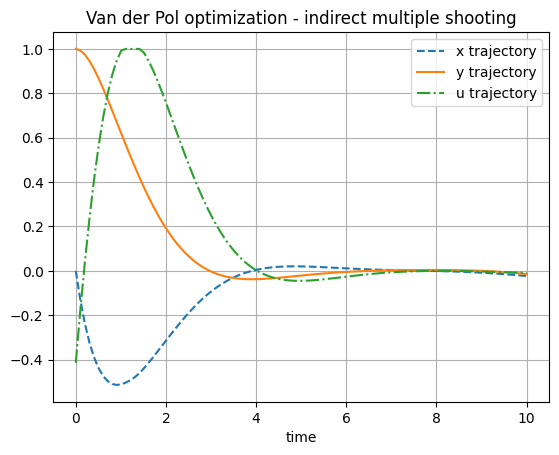

[[-2.11224e-36, -0.130515, -0.237359, -0.322603, -0.388704, -0.438177, -0.473397, -0.496514, -0.509421, -0.513759, -0.510945, -0.503101, -0.492345, -0.478205, -0.460097, -0.437959, -0.413844, -0.388473, -0.362304, -0.335733, -0.309112, -0.282745, -0.256893, -0.23178, -0.207593, -0.184482, -0.162569, -0.141945, -0.122672, -0.10479, -0.0883141, -0.0732416, -0.0595518, -0.0472099, -0.0361686, -0.0263713, -0.0177535, -0.010245, -0.00377188, 0.00174211, 0.00637418, 0.0102013, 0.0132991, 0.0157413, 0.0175987, 0.0189391, 0.0198265, 0.0203209, 0.0204784, 0.0203505, 0.0199849, 0.0194248, 0.0187092, 0.0178732, 0.0169479, 0.0159608, 0.0149357, 0.0138933, 0.012851, 0.0118235, 0.0108225, 0.00985764, 0.00893604, 0.00806285, 0.00724135, 0.00647315, 0.00575834, 0.00509566, 0.00448266, 0.00391581, 0.00339066, 0.00290194, 0.00244367, 0.00200927, 0.00159164, 0.00118327, 0.000776323, 0.000362702, -6.58424e-05, -0.000517637, -0.001001, -0.00152412, -0.002095, -0.00272132, -0.00341032, -0.00416865, -0.00500

In [33]:
#
#     MIT No Attribution
#
#     Copyright (C) 2010-2023 Joel Andersson, Joris Gillis, Moritz Diehl, KU Leuven.
#
#     Permission is hereby granted, free of charge, to any person obtaining a copy of this
#     software and associated documentation files (the "Software"), to deal in the Software
#     without restriction, including without limitation the rights to use, copy, modify,
#     merge, publish, distribute, sublicense, and/or sell copies of the Software, and to
#     permit persons to whom the Software is furnished to do so.
#
#     THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED,
#     INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A
#     PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT
#     HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION
#     OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE
#     SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
#
from casadi import *
import numpy as NP
import matplotlib.pyplot as plt

# Declare variables (use simple, efficient DAG)
x0=SX.sym("x0"); x1=SX.sym("x1")
x = vertcat(x0,x1)

# Control
u = SX.sym("u")

# ODE right hand side
xdot = vertcat((1 - x1*x1)*x0 - x1 + u, x0)

# Lagrangian function
L = x0*x0 + x1*x1 + u*u

# Costate
lam = SX.sym("lam",2)

# Hamiltonian function
H = dot(lam,xdot) + L

# Costate equations
ldot = -gradient(H,x)

## The control must minimize the Hamiltonian, which is:
print("Hamiltonian: ", H)

# H is of a convex quadratic form in u: H = u*u + p*u + q, let's get the coefficient p
p = gradient(H,u)     # this gives us 2*u + p
p = substitute(p,u,0) # replace u with zero: gives us p

# H's unconstrained minimizer is: u = -p/2
u_opt = -p/2

# We must constrain u to the interval [-0.75, 1.0], convexity of H ensures that the optimum is obtain at the bound when u_opt is outside the interval
u_opt = fmin(u_opt,1.0)
u_opt = fmax(u_opt,-0.75)
print("optimal control: ", u_opt)

# Augment f with lam_dot and subtitute in the value for the optimal control
f = vertcat(xdot,ldot)
f = substitute(f,u,u_opt)

# Function for obtaining the optimal control from the augmented state
u_fcn = Function("ufcn", [vertcat(x,lam)], [u_opt])

# Formulate the DAE
dae = {'x':vertcat(x,lam), 'ode':f}

# Augmented DAE state dimension
nX = 4

# End time
tf = 10.0

# Number of shooting nodes
num_nodes = 20

# Create an integrator (CVodes)
iopts = {}
iopts["abstol"] = 1e-8 # abs. tolerance
iopts["reltol"] = 1e-8 # rel. tolerance
I = integrator("I", "cvodes", dae, 0, tf/num_nodes, iopts)

# Variables for the states at each shooting node
X = MX.sym('X',nX,num_nodes+1)

# Formulate the root finding problem
G = []
G.append(X[:2,0] - vertcat(0,1)) # states fixed, costates free at initial time
for k in range(num_nodes):
  XF = I(x0=X[:,k])["xf"]
  G.append(XF-X[:,k+1])
G.append(X[2:,num_nodes] - vertcat(0,0)) # costates fixed, states free at final time

# Terminal constraints: lam = 0
rfp = {"x": vec(X), "g": vertcat(*G)}

# Select a solver for the root-finding problem
Solver = "nlpsol"
#Solver = "newton"
#Solver = "kinsol"

# Solver options
opts = {}
if Solver=="nlpsol":
    opts["nlpsol"] = "ipopt"
    opts["nlpsol_options"] = {"ipopt.hessian_approximation":"limited-memory"}
elif Solver=="newton":
    opts["linear_solver"] = "csparse"
elif Solver=="kinsol":
    opts["linear_solver_type"] = "user_defined"
    opts["linear_solver"] = "csparse"
    opts["max_iter"] = 1000

# Allocate a solver
solver = rootfinder('solver', Solver, rfp, opts)

# Solve the problem
X_sol = solver(x0=0)['x']
print(X_sol)

# Time grid for visualization
tgrid = NP.linspace(0,tf,100)

# Simulator to get optimal state and control trajectories
simulator = integrator('simulator', 'cvodes', dae, 0, tgrid)

# Simulate to get the trajectories
sol = simulator(x0 = X_sol[0:4])["xf"]

# Calculate the optimal control
u_opt = u_fcn(sol)

# Plot the results
plt.figure(1)
plt.clf()
plt.plot(tgrid, sol[0, :].T, '--')
plt.plot(tgrid, sol[1, :].T, '-')
plt.plot(tgrid, u_opt.T, '-.')
plt.title("Van der Pol optimization - indirect multiple shooting")
plt.xlabel('time')
plt.legend(['x trajectory','y trajectory','u trajectory'])
plt.grid()
plt.show()

print(sol[0,:])

Integrator

Integrate ODE from time t0 to tf  with initial conditions x0

1. idas, cvodes- stiff dynamical systems 
2. more accurate than RK45 fixed step

In [34]:
x=cs.SX.sym('x',1)
u=cs.SX.sym('u',1)
xdot=-x+u
dae={'x':x,'u':u,'ode':xdot}
t=np.linspace(0,10,50)
I=cs.integrator('I','idas',dae,t[0],t[1:])
print(I(x0=100,u=10))


{'adj_p': DM(0x0), 'adj_u': DM(0x0), 'adj_x0': DM(0x0), 'adj_z0': DM(0x0), 'qf': DM(0x49), 'xf': DM([[83.3857, 69.8384, 58.792, 49.7848, 42.4404, 36.4518, 31.5687, 27.587, 24.3404, 21.6931, 19.5345, 17.7744, 16.3392, 15.1689, 14.2147, 13.4367, 12.8022, 12.2849, 11.8631, 11.5192, 11.2387, 11.0101, 10.8236, 10.6716, 10.5476, 10.4465, 10.3641, 10.2969, 10.2421, 10.1974, 10.1609, 10.1312, 10.107, 10.0873, 10.0711, 10.058, 10.0473, 10.0386, 10.0315, 10.0256, 10.0209, 10.0171, 10.0139, 10.0113, 10.0092, 10.0075, 10.0061, 10.005, 10.0041]]), 'zf': DM(0x49)}


Ode with time varying control 

Nonlinear programming

Solve :  

$$\begin{equation}
\begin{aligned}
\mathrm{min}~~ &f(x,p) \\
x_l &\leq x \leq x_u\\
g_l &\leq g(x,p) \leq g_u
\end{aligned}
\end{equation}
$$

1. p is a parameter
2. $x_l,\dots,g_u$ are bounds
3. The inputs are  guess solution for primal $x_0$ and multiplier also called dual  $\lambda_0$

NPSOl

It solves the  optimization problem in the above form.
$$\begin{equation}
\begin{aligned}
\mathrm{min}~~ &x^2+100z^2 \\
&z-y+(1-x)^2=0
\end{aligned}
\end{equation}
$$

1. Write the optimization problem in the given form
2. For equality, set upper and lower bound to be equal
3. Notice that only one multiplier for both side bounded constraint, it practice this must be 2
4. The solution is stored as a dictionary


In [35]:
x=cs.SX.sym('x',1)
z=cs.SX.sym('z',1)
y=cs.SX.sym('y',1)
f=x**2 + 100*z**2
g=z+(1-x)**2-y

w=cs.vertcat(x,y,z)

nlp={'x':w,'f':f,'g':g}

prob=cs.nlpsol('rosebrook','ipopt',nlp)
print(prob)
sol=prob(x0=[1,2,3],lbg=0,ubg=0)
print(sol['f'])

rosebrook:(x0[3],p[],lbx[3],ubx[3],lbg,ubg,lam_x0[3],lam_g0)->(x[3],f,g,lam_x[3],lam_g,lam_p[]) IpoptInterface
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        3
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        2

Total number of variables............................:        3
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||

QP solver

QPs can be solved using 2 methods

1. low level - conic (supply hessian, gradient, jacobian)
2. high level - qpsol 

Some inbuilt solvers are

1. qpoases
2. osqp
3. proxqp
4. qrqp
   

$$\begin{equation}
\begin{aligned}
\mathrm{min}~~ &x^2+y^2 \\
&x+y-10 \geq 0
\end{aligned}
\end{equation}
$$

The objective should be convex and constraints should be linear

In [36]:
x=cs.SX.sym('x',1)
y=cs.SX.sym('y',1)
f=x**2+y**2
g=x+y-10
w=cs.vertcat(x,y)
qp={'x':w,'f':f,'g':g}
prob=cs.qpsol('qp','qpoases',qp)
print(prob)
sol=prob(lbg=0,ubg=cs.inf)
print(sol['x'])



qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.

qp:(x0[2],p[],lbx[2],ubx[2],lbg,ubg,lam_x0[2],lam_g0)->(x[2],f,g,lam_x[2],lam_g,lam_p[]) MXFunction

qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
S

Low level interface

Any advantages?

$$\begin{equation}
\begin{aligned}
\mathrm{min}~~ &\frac{1}{2}x^THx+c^Tx \\
 x_l& \leq x \leq x_u\\
 a_l& \leq Ax \leq a_u\\
\end{aligned}
\end{equation}
$$

The QP must be brought to the desired form

In [37]:
H=2*cs.DM.eye(2)
c=cs.DM.zeros(2,1)
A=cs.DM.ones(1,2)
lba=10

qp={}
qp['h']=H.sparsity()
qp['a']=A.sparsity()


prob=cs.conic('qp','qpoases',qp)

print(prob)

sol=prob(h=H,g=c,a=A,lba=lba)

print(sol['x'])





qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.

qp:(h[2x2,2nz],g[2],a[1x2],lba,uba,lbx[2],ubx[2],x0[2],lam_x0[2],lam_a0,q[],p[])->(x[2],cost,lam_a,lam_x[2]) QpoasesInterface


####################   qpOASES  --  QP NO.   1   #####################

    Iter   |    StepLength    |       Info       |   nFX   |   nAC    
 ----------+------------------+------------------+---------+--------- 
       0   |   1.866661e-07   |   ADD CON    0   |     1   |     1   
       1   |   8.333622e-10   |   REM BND    1   |     0   |     1   
       2   |   1.000000e+00   |    QP 

For loop equivalent

Helps to reduce complexity of expression graph, lowers the nodes

1. map
2. fold
3. mapaccum

In [38]:
x=cs.MX.sym('x',1,100)
y=[]

for i in range(100):
    
    y.append(cs.sin(x[i]))

y=cs.hcat(y)

print(type(y))
print('for loop nodes',cs.n_nodes(y))

x1=cs.SX.sym('x1',1)
y1=cs.sin(x1)
f=cs.Function('f',[x1],[y1])
F=f.map(100)

Y=F(x)

print('map nodes',cs.n_nodes(Y))




<class 'casadi.casadi.MX'>
for loop nodes 301
map nodes 3


Conditional functions

let $f_0,f_1,f_2$ be function objects. The $f_{cond}$ is the conditional function which executes as follows

$$
\begin{equation}
\begin{aligned}
f_{cond}(c,x)&=f_0(x), ~~\mathrm{if}~c=0\\ 
             &~~~~~f_1(x), ~~\mathrm{if}~c=1\\
             &~~~~~f_2(x),  ~~\mathrm{if}~c=\mathrm{otherwise}
\end{aligned}
\end{equation}
$$

1. the parameter c is a additional argument (first one)
2. the derivatives can be calculated for $f_{cond}$
   

In [39]:
x = cs.SX.sym("x")
f0 = cs.Function("f0",[x],[cs.sin(x)])
f1 = cs.Function("f1",[x],[cs.cos(x)])
f2 = cs.Function("f2",[x],[cs.tan(x)])
f_cond = cs.Function.conditional('f_cond', [f0, f1], f2)
print(f_cond)
print('tan(90)',f_cond(5,cs.pi/2))
print('sin(90)',f_cond(0,cs.pi/2))
print('cos(90)',f_cond(1,cs.pi/2))

f_cond:(i0,i1)->(o0) Switch
tan(90) 1.63312e+16
sin(90) 1
cos(90) 6.12303e-17


if else function

1. if else a special case of $f_{cond}$ with one case and the otherwise
2. short hand in casadi
3. check below code

In [40]:
x = cs.SX.sym("x")
f_true = cs.Function("f_true",[x],[cs.cos(x)])
f_false = cs.Function("f_false",[x],[cs.sin(x)])
f_cond = cs.Function.if_else('f_cond', f_true, f_false)
print(f_cond)
print('sin(90)',f_cond(1,cs.pi/2))
print('cos(90)',f_cond(0,cs.pi/2))

f_cond:(i0,i1)->(o0) Switch
sin(90) 6.12303e-17
cos(90) 1


Code generation

1. Numerical evaluation
   1. virtual machines
   2. C code generation

Function objects can be converted to C code.

code generation advantages

1. speed up
2. embedded system
3. independence from casadi
4. mirror of operations happening in virtual machine
   1. gprof can be used to check bottlenecks in code
   2. longer compile time implies function needs to broken to smaller functions (nested functions)

Creates C code containing all dependencies and header files

In [41]:
x = cs.MX.sym('x',2)
y = cs.MX.sym('y')
f = cs.Function('f',[x,y],[x,cs.sin(y)*x],['x','y'],['r','q'])
f.generate('gen.c',{'cpp':True,'main':True})
print(open('gen.c','r').read())

/* This file was automatically generated by CasADi 3.6.3.
 *  It consists of: 
 *   1) content generated by CasADi runtime: not copyrighted
 *   2) template code copied from CasADi source: permissively licensed (MIT-0)
 *   3) user code: owned by the user
 *
 */
/* How to prefix internal symbols */
#ifdef CASADI_CODEGEN_PREFIX
  #define CASADI_NAMESPACE_CONCAT(NS, ID) _CASADI_NAMESPACE_CONCAT(NS, ID)
  #define _CASADI_NAMESPACE_CONCAT(NS, ID) NS ## ID
  #define CASADI_PREFIX(ID) CASADI_NAMESPACE_CONCAT(CODEGEN_PREFIX, ID)
#else
  #define CASADI_PREFIX(ID) gen_ ## ID
#endif

#include <math.h>
#include <stdio.h>
#include <string.h>

#ifndef casadi_real
#define casadi_real double
#endif

#ifndef casadi_int
#define casadi_int long long int
#endif

/* Add prefix to internal symbols */
#define casadi_copy CASADI_PREFIX(copy)
#define casadi_f0 CASADI_PREFIX(f0)
#define casadi_s0 CASADI_PREFIX(s0)
#define casadi_s1 CASADI_PREFIX(s1)

/* Symbol visibility in DLLs */
#ifndef CASADI_SYMBOL_EXPORT

Codegenerator class

1. add multiple functions to 1 C/C++ file
2. additional options to modify the c/c++ file
   1. .generate(,dict)
   2. codegenrator('a.c',dict)
   3. {'cpp':True}, etc..


Option |Default value| Description
---|---|---
verbose |true| Include comments in generated code
mex |false| Generate an MATLAB/Octave MEX entry point
cpp |false |Generated code is C++ instead of C
main |false |Generate a command line interface
casadi_real |double |Floating point type
casadi_int |long long int |Integer type
with_header| false| Generate a header file
with_mem |false |Generate a simplified C API
indent |2 |Number of spaces per indentation level

In [42]:
x=cs.SX.sym('x',1,1)
f = cs.Function('f',[x],[cs.sin(x)])
g = cs.Function('g',[x],[cs.cos(x)])
C = cs.CodeGenerator('gen.cpp',{'cpp':True})
C.add(f)
C.add(g)
C.generate()

'gen.cpp'

How to use the C/C++ code

1. command line/terminal- gprof to profile code
2. mex file for matlab
3. C-API - use API of generated code to link the function statically or dynamically
4. compile the function into a dynamically linked library (DLL) and access the API via dlopen/LoadLibrary
   1. The DLL can be accessed in casadi interface via external() function. (JIT rely optionally ?)

Library is similar to module

1. C++ is a compiled language
   1. library can be combined with source code to get a single executable (only a single file is executed) (static linrary)
   2. library can be separately listed along with  source code's executable as DLL (dynamic link libraries- many files required to execute cpp code) 

A c/c++ comipler must be installed and the c code must be converted to a shared library (.so) files first. Then, the C++ code can be executed from casadi interface via the external function

The following code throws an error because the compiler is not installed and the .so file was not created.


Install mysys64 based on VScode website and the run the command from terminal

```
gcc -fPIC -shared gen.c -o gen.so
```


In [43]:
x = cs.MX.sym('x',2)
y = cs.MX.sym('y')
f = cs.Function('f',[x,y],[x,cs.sin(y)*x],['x','y'],['r','q'])
f.generate('gen.c',{'cpp':False,'main':True})
f=cs.external('f','./gen.so')
print(f)
print(f([1,5],1))

f:(x[2],y)->(r[2],q[2]) External
(DM([1, 5]), DM([0.841471, 4.20735]))


Alternatively, one can use the importer class to execute the C code. Casadi is shipped with clang compiler.

In [44]:
x = cs.MX.sym('x',2)
y = cs.MX.sym('y')
f = cs.Function('f',[x,y],[x,cs.sin(y)*x],['x','y'],['r','q'])
f.generate('gen.c')
C = cs.Importer('gen.c','shell')
f = cs.external('f',C)

CasADi - 2023-11-03 01:39:25 WARNING("Failed to remove tmp_casadi_compiler_shell1e7bxb.dll") [.../casadi/solvers/shell_compiler.cpp:66]


RuntimeError: .../casadi/solvers/shell_compiler.cpp:231: Compilation failed. Tried "cl.exe /c gen.c /Fotmp_casadi_compiler_shell1e7bxb.obj"

Callback

1. A function is natively written in C++/MATLAB/Python
2. re-writing the function in casadi not easy
3. Use callback
   1. black box function to casadi function
4. Disadvantage- not efficient compared to symbolic primitives

Ways to use call back


In [ ]:
class MyCallback(cs.Callback):
    def __init__(self, name, d, opts={}):
        cs.Callback.__init__(self)
        self.d = d
        self.construct(name, opts)
    # Number of inputs and outputs
    def get_n_in(self): return 1
    def get_n_out(self): return 1
    # Initialize the object
    def init(self):
        print('initializing object')
    # Evaluate numerically
    def eval(self, arg):
        x = arg
        f = cs.sin(self.d*x)
        return [f]
    
f=MyCallback('f',0.5)
print(f.eval(2))    

initializing object
[0.8414709848078965]


CSE

Common sub-expression elimination to simplify the expression graph and improve speed

In [ ]:
x=cs.SX.sym('x',3,1)
D=cs.DM_rand(3,3)
print(D.shape)
print(x.shape)
print((D@x).shape)
print(cs.cse(D@(x)-D@(x)))


(3, 3)
(3, 1)
(3, 1)
@1=0, [@1, @1, @1]


Look tables

1. If data points are available for y=f(x) or z=f(x,y)
2. create differentiable lookup table
3. interpolation type- linear and bspline

y=f(x)

In [ ]:
xgrid = np.linspace(1,6,6)
V = [-1,-1,-2,-3,0,2]
lut = cs.interpolant('LUT','bspline',[xgrid],V)
print(lut(2.5))
print(type(lut(2.5)))


-1.35
<class 'casadi.casadi.DM'>


z=f(x,y)

In [ ]:
xgrid = np.linspace(-5,5,11)
ygrid = np.linspace(-4,4,9)
X,Y = np.meshgrid(xgrid,ygrid,indexing='ij')
R = np.sqrt(5*X**2 + Y**2)+ 1
data = np.sin(R)/R
data_flat = data.ravel(order='F')
lut = cs.interpolant('name','bspline',[xgrid,ygrid],data_flat)
print(lut([0.5,1]))

0.245507


FInite difference instead of AD

more details required

In [ ]:
x=cs.SX.sym('x',3,1)
y=cs.vcat([x[0]**2, x[1]**5, cs.exp(x[2]**0.4)])
f_fd=cs.Function('f_fd',[x],[y],{'enable_fd':True,'enable_forward':False,'enable_reverse':False,'enable_jacobian':False})
f_ad=cs.Function('f_ad',[x],[y])

j_fd=cs.jacobian(f_fd(x),x)
J_fd=cs.Function('J_fd',[x],[j_fd])
j_ad=cs.jacobian(f_ad(x),x)
J_ad=cs.Function('J_ad',[x],[j_ad])
inp=np.array([[1, 1, 1]]).T
print('AD',cs.evalf(J_ad(inp)))
print('FD',cs.evalf(J_fd(inp)))


AD 
[[2, 00, 00], 
 [00, 5, 00], 
 [00, 00, 1.08731]]
FD 
[[2, 00, 00], 
 [00, 5, 00], 
 [00, 00, 1.08731]]


Optistack

A modelling language for optimization in casadi. Invokes using the Opti class in casadi.

1. natural syntax
2. index of decision vars is hidden
3. Closer mapping of numerical data-type to the host language: no encounter with DM.
4. Default: NLP, pass 'conic' as argument to solve QP

The main components are 
1. decision variables- MX 
2. parameters- MX 
3. objective function
4. constraints
5. solver
6. retrieve solution

If solver did not converge to a solution, the cause can be analyzed using a few tools provided by casadi

1. check infeasibility
2. check if any variable is NaN


In [ ]:
opti = cs.Opti()
#  decision variables
x = opti.variable()
y = opti.variable()
print(type(x))
#objective function
opti.minimize( (y-x**2)**2 )
#constraints
opti.subject_to( x**2+y**2==1 )
opti.subject_to( x+y>=1 )
#solver
opti.solver('ipopt')
sol = opti.solve()
# retrieve solution 
print(sol.value(x))
print(type(sol.value(x)))
print(sol.value(y))

<class 'casadi.casadi.MX'>
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.00e+00 1.00e+00  -1.0 0.00e+


create the decision variables

```
#scalar
x = opti.variable() 
#column vector
x = opti.variable(5) 
#matrix
x = opti.variable(5,3) 
symmetric matrix
x = opti.variable(5,5,'symmetric')
```

create parameter scalar/vector/matrix if NLP is parametric
```
# create parameter
p = opti.parameter()
# set the value of the parameter before solving
opti.set_value(p, 3)
```
Add constraints
```
#equality
opti.subject_to( sqrt(x+y) == 1) 
#inequality
opti.subject_to( sqrt(x+y) > 1)
opti.subject_to( 1<= sqrt(x+y) )
#equality
opti.subject_to( 5*x+y==1 ) 
```

Add multiple constraints using list
```
opti.subject_to([x*y>=1,x==3])
```

Constraints bounded from below and above
```
opti.subject_to( opti.bounded(0,x,1) )
```

vector inequality - applied element-wise
```
x = opti.variable(5,1)
opti.subject_to( x*p<=3 )
```

Matrix inequality -no support for element wise
caveat- vectorize matrix
```
A = opti.variable(5,5)
opti.subject_to( vec(A)<=3 )
```

Empty call of subject_to will clear all constraints
```
opti.subject_to()
```

Solver options can be passed as dict
```
p_opts = {"expand":True}
s_opts = {"max_iter": 100}
opti.solver("ipopt",p_opts,s_opts)
```

initial guess for solver

```
opti.set_initial(x, 2)
opti.set_initial(10*x[0], 2)
```




Solver warm-start

1. solving similar set of optimization problems
2. reduces iterations $\implies$ lower computational time
3. IP methods resistant, more suitable for active set methods

```
sol1 = opti.solve()
print(sol1.stats()["iter_count"])
# Solving again makes no difference
sol1 = opti.solve()
print(sol1.stats()["iter_count"])
# Passing initial makes a difference
opti.set_initial(sol1.value_variables())
# dual variables
lam_g0 = sol1.value(opti.lam_g)
opti.set_initial(opti.lam_g, lam_g0)
sol2 = opti.solve()
print(sol2.stats()["iter_count"])
```


Inspect numerical values at solution

```
#value of a decision variable
sol.value(x)
#value of a parameter
sol.value(p)
#value of an expression
sol.value(sin(x+p))
#value of constraint jacobian
sol.value(jacobian(opti.g,opti.x))
```
 


numerical value at other points

1. does not affect the original solution

```
obj = (y-x**2)**2
opti.minimize(obj)
print(sol.value(obj,[y==2]))
```

A related usage pattern is to evaluate an expression at the initial guess

```
print(sol.value(x**2+y,opti.initial()))
```


Dual variable of constraints

In order to obtain dual variables (Lagrange multipliers) of constraints, make sure you save the constraint expression
first.

```
con = sin(x+y)>=1
opti.subject_to(con)
sol = opti.solve()
print(sol.value(opti.dual(con)))
```


Debugging solution

1. access non converged solution
   1. ```opti.debug.value(x)```
2. inspect at initial guess
   1. ```opti.debug.value(x,opti.initial())```
3. failure due to infeasibility- identify constraints
   1. ```opti.debug.show_infeasibilities()```
4. failure due to varibale blowing up (division by zero)
   1. ```opti.debug.x_describe(index)```
   2. ```opti.debug.g_describe(index)```

You may specify a callback function; it will be called at each iteration of the solver, with the current iteration number
as argument. To plot the progress of the solver, you may access the non-converged solution through debug mode:

```
opti.callback(lambda i: plot(opti.debug.value(x)))
```

You may construct a regular CasADi Function out of an Opti object, by calling the to_function function. The
supplied list of input arguments may contain parameters, decision variables and dual variables. Inputs corresponding
to variables are taken as initial guesses. If you desire this Function to throw a runtime error when the solver fails, you
may pass the error_on_fail as solver option.

```
f = opti.to_function("f",[x,y],[x**2+y])
print(f(0, 0))
```

Concatenate matrices along the block diagonal

Let A1,A2,A3 etc. be matrices. We want the matrix 

$$


\begin{bmatrix}
A1&0&0\\
0&\ddots&0\\
0&0&A_N
\end{bmatrix}

$$

This can be achieved using diagcat command, which performs diagonal concatenation.

This is typical while solving optimal control problems and one needs to write his own optimization algorithm for maximum performance.
Use a map function to evaluate the state and control matrices. Split them using horsplit_n into N parts and arrange them along the block diagonal.
*arg is used when number of arguments is a variable.



In [ ]:
A=cs.DM_rand(5,20)
print((cs.horzsplit_n(A,4)))
B=cs.diagcat(*(cs.horzsplit_n(A,4)))


[DM(
[[0.22422, 0.456044, 0.148485, 0.561858, 0.578522], 
 [0.198708, 0.247563, 0.317899, 0.610475, 0.450582], 
 [0.628031, 0.990265, 0.887756, 0.385221, 0.307678], 
 [0.790918, 0.927224, 0.251457, 0.897874, 0.121071], 
 [0.174112, 0.0829107, 0.388101, 0.295372, 0.697941]]), DM(
[[0.379056, 0.88327, 0.78393, 0.966819, 0.0184993], 
 [0.0348109, 0.606736, 0.466327, 0.89613, 0.0835], 
 [0.715975, 0.208632, 0.120088, 0.0137915, 0.331805], 
 [0.561988, 0.501001, 0.0864238, 0.93764, 0.254725], 
 [0.0398156, 0.114018, 0.815111, 0.017067, 0.639156]]), DM(
[[0.428193, 0.61304, 0.785961, 0.416535, 0.433173], 
 [0.61135, 0.516402, 0.388047, 0.55869, 0.812284], 
 [0.602262, 0.947562, 0.375819, 0.306724, 0.207217], 
 [0.6008, 0.93871, 0.118083, 0.331993, 0.238941], 
 [0.812053, 0.990106, 0.016387, 0.54616, 0.00996133]]), DM(
[[0.924863, 0.628587, 0.821501, 0.263146, 0.230085], 
 [0.43343, 0.639409, 0.477482, 0.336867, 0.597453], 
 [0.903134, 0.0660869, 0.497439, 0.590295, 0.798175], 
 [0.571439, 0.

Another way to do the same is via a for loop.

In [ ]:
A=cs.DM_rand(5,20)
B=cs.horzsplit_n(A,4)

for i in range(len(B)):
    
    if i==0:
        C=B[i]
    else:    
        C=cs.diagcat(C,B[i])

print(C)        


sparse: 20-by-20, 100 nnz
 (0, 0) -> 0.719813
 (1, 0) -> 0.264336
 (2, 0) -> 0.753597
 (3, 0) -> 0.341295
 (4, 0) -> 0.902545
 (0, 1) -> 0.34589
 (1, 1) -> 0.194903
 (2, 1) -> 0.529312
 (3, 1) -> 0.977873
 (4, 1) -> 0.837749
 (0, 2) -> 0.932888
 (1, 2) -> 0.190367
 (2, 2) -> 0.867067
 (3, 2) -> 0.660655
 (4, 2) -> 0.856544
 (0, 3) -> 0.263548
 (1, 3) -> 0.396765
 (2, 3) -> 0.209643
 (3, 3) -> 0.592832
 (4, 3) -> 0.321738
 (0, 4) -> 0.0953908
 (1, 4) -> 0.0264092
 (2, 4) -> 0.697989
 (3, 4) -> 0.820065
 (4, 4) -> 0.116777
 (5, 5) -> 0.741492
 (6, 5) -> 0.288825
 (7, 5) -> 0.131083
 (8, 5) -> 0.648838
 (9, 5) -> 0.623176
 (5, 6) -> 0.58254
 (6, 6) -> 0.203273
 (7, 6) -> 0.301778
 (8, 6) -> 0.70863
 (9, 6) -> 0.476522
 (5, 7) -> 0.554138
 (6, 7) -> 0.0458682
 (7, 7) -> 0.895084
 (8, 7) -> 0.442579
 (9, 7) -> 0.777953
 (5, 8) -> 0.594961
 (6, 8) -> 0.461157
 (7, 8) -> 0.0598989
 (8, 8) -> 0.242973
 (9, 8) -> 0.648862
 (5, 9) -> 0.218571
 (6, 9) -> 0.154169
 (7, 9) -> 0.296899
 (8, 9) -> 0.

Apply the technique on a symbolic matrix

In [ ]:
A=cs.SX.sym('A',2,10)
B=cs.horzsplit_n(A,2)

for i in range(len(B)):
    
    if i==0:
        C1=B[i]
    else:    
        C1=cs.diagcat(C,B[i])


C2=cs.diagcat(*B)

print('* method',cs.n_nodes(C2),'for loop method',cs.n_nodes(C1))      

* method 20 for loop method 30


CHeck the number of nodes in the expression graph

In [ ]:
X=cs.SX.sym('X',12,12)
Y=cs.sin(cs.exp(X**2))
print(cs.n_nodes(Y))

f=cs.Function('f',[X],[Y])

Xmat=cs.MX.sym('Xmat',12,12*100)

I=cs.horzsplit_n(Xmat,100)

j=0

for i in I:

    if j==0:
        Yf=f(i)
        j=j+1
    else:    
        Yf=cs.horzcat(Yf,f(i))
        j=j+1

print('For loop',cs.n_nodes(Yf))

fm=f.map(100)
Ym=fm(Xmat)

print('Map',cs.n_nodes(Ym))

print(cs.cse(Yf-Ym).is_zero())



576
For loop 202
Map 3
False


Check if both are equal

In [ ]:
import time

X=cs.SX.sym('X',12,12)
Y=cs.sin(cs.exp(X**2))
print(cs.n_nodes(Y))

f=cs.Function('f',[X],[Y])
N=1000
Xmat=cs.SX.sym('Xmat',12,12*N)

I=cs.horzsplit_n(Xmat,N)

j=0


for i in I:

    if j==0:
        Yf=f(i)
        j=j+1
    else:    
        Yf=cs.horzcat(Yf,f(i))
        j=j+1

f_Yf=cs.Function('f_Yf',[Xmat],[Yf])
INP=np.random.rand(12,12*N)

t1=time.time()
for i in range(100):
    f_Yf(INP)
t2=time.time()

print('For loop time',(t2-t1)/100,'secs')

fm=f.map(N,'thread',4)

Ym=fm(Xmat)

f_Ym=cs.Function('f_Ym',[Xmat],[Ym])

t1=time.time()
#(f_Ym(INP)).full()
for i in range(100):
    fm(INP)
t2=time.time()

print('Map time',(t2-t1)/100,'secs')

print('Diff is zero',(Yf-Ym).is_zero())



576
For loop time 0.023496601581573486 secs
Map time 0.024203784465789795 secs
Diff is zero False


In [ ]:
#
#     MIT No Attribution
#
#     Copyright (C) 2010-2023 Joel Andersson, Joris Gillis, Moritz Diehl, KU Leuven.
#
#     Permission is hereby granted, free of charge, to any person obtaining a copy of this
#     software and associated documentation files (the "Software"), to deal in the Software
#     without restriction, including without limitation the rights to use, copy, modify,
#     merge, publish, distribute, sublicense, and/or sell copies of the Software, and to
#     permit persons to whom the Software is furnished to do so.
#
#     THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED,
#     INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A
#     PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT
#     HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION
#     OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE
#     SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
#
import numpy as np
import time
print("importing casadi...")
from casadi import *


# number of inputs to evaluate in parallel
N = 300


# dummy input
dummyInput = np.linspace(0.0, 2.0*np.pi, N)


# make a dummy function that's moderately expensive to evaluate
print("creating dummy function....")
x = SX.sym('x')
y = x
for k in range(100000):
    y = sin(y)
f0 = Function('f', [x], [y])


# evaluate it serially, the old-fasioned way
X = MX.sym('x',N)
Y = vertcat(*[f0(X[k]) for k in range(N)])
fNaiveParallel = Function('fParallel', [X], [Y])

print("evaluating naive parallel function...")
t0 = time.time()
outNaive = fNaiveParallel(dummyInput)
t1 = time.time()
print("evaluated naive parallel function in %.3f seconds" % (t1 - t0))


# evaluate it using new serial map construct
fMap = f0.map(N)

print("evaluating serial map function...")
t0 = time.time()
outMap = fMap(dummyInput)
t1 = time.time()
print("evaluated serial map function in %.3f seconds" % (t1 - t0))
# the following has different shaped outputs, so it's commented out
#print outNaive == outMap


# evaluate it using new parallel map construct
fMap = f0.map(N, "thread",4)

print("evaluating parallel map function...")
t0 = time.time()
outMap = fMap(dummyInput)
t1 = time.time()
print("evaluated parallel map function in %.3f seconds" % (t1 - t0))
# the following has different shaped outputs, so it's commented out
#print outNaive == outMap

importing casadi...
creating dummy function....
evaluating naive parallel function...
evaluated naive parallel function in 1.583 seconds
evaluating serial map function...
evaluated serial map function in 1.568 seconds
evaluating parallel map function...
evaluated parallel map function in 0.947 seconds


In [ ]:
x = SX.sym('x'); y = SX.sym('y')
qp = {'x':vertcat(x,y), 'f':x**2+y**2, 'g':x+y-10}
S = qpsol('S', 'hpipm', qp,{'hpipm':{'mode':'balance','iter_max':1000},'error_on_fail':False})
print(S)
r = S(lbg=0)
x_opt = r['x']
print('x_opt: ', x_opt)


nx,nu,ng[1, 1][0, 0][0, 0]
nus[0, 0, 0]
nu3:1
0
55
2
23
S:(x0[2],p[],lbx[2],ubx[2],lbg,ubg,lam_x0[2],lam_g0)->(x[2],f,g,lam_x[2],lam_g,lam_p[]) MXFunction
HPIPM finished after 1000 iterations.
return status: 1
HPIPM residuals: 0, 0, 0, 1e-08
